In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Função auxiliar para exibir as imagens no formato correto dentro do Notebook
def show_image(title, img, cmap=None, figsize=(8, 6)):
    plt.figure(figsize=figsize)
    if cmap is None:
        # Se for imagem colorida, converte de BGR (OpenCV) para RGB (Matplotlib)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
    else:
        # Para imagens em tons de cinza (como bordas do Canny)
        plt.imshow(img, cmap=cmap)
    
    plt.title(title)
    plt.axis('off')
    plt.show()

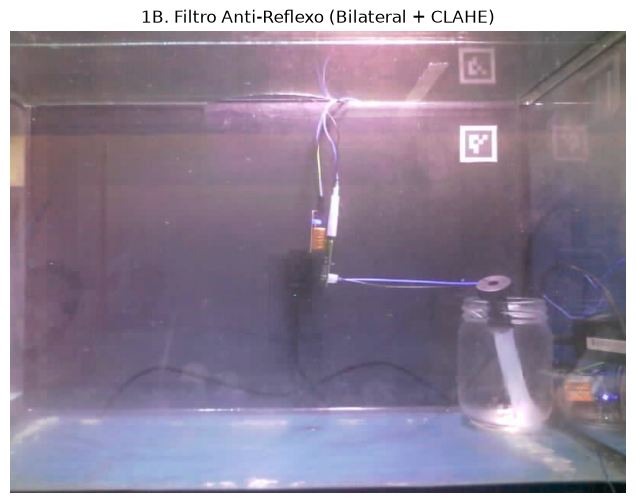

[OK] ArUco detectado (DICT_4X4_50)
Largura do ArUco na imagem: 33.0 pixels


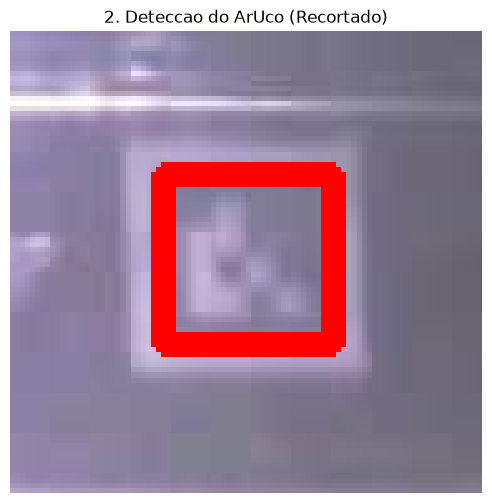

In [ ]:
import cv2
import numpy as np

image_path = "../pictures/kampu_1788450876.jpg"
image = cv2.imread(image_path)
image_debug = image.copy()
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# --- PIPELINE ANTI-REFLEXO ---
# 1. Filtro Bilateral: Suaviza reflexos mantendo as bordas afiadas
# Parâmetros: (imagem, diâmetro, sigmaColor, sigmaSpace)
# gray_filtered = cv2.bilateralFilter(gray, 11, 75, 75)

# 2. CLAHE: Melhora o contraste localmente para "vencer" o ofuscamento da luz
# clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
# gray_filtered = clahe.apply(gray_filtered)

# Vamos exibir como a imagem ficou após o filtro (opcional, para você ver a diferença)
show_image("1B. Filtro Anti-Reflexo (Bilateral + CLAHE)", gray, cmap='gray')

# Dicionários comuns para varredura
aruco_dicts = {
    "DICT_4X4_50": cv2.aruco.DICT_4X4_50,
    "DICT_5X5_100": cv2.aruco.DICT_5X5_100,
    "DICT_6X6_250": cv2.aruco.DICT_6X6_250,
    "DICT_ARUCO_ORIGINAL": cv2.aruco.DICT_ARUCO_ORIGINAL
}

aruco_corners_found = None
w_aruco_px = 0
aruco_cropped = None

for name, dict_id in aruco_dicts.items():
    aruco_dict = cv2.aruco.getPredefinedDictionary(dict_id)
    aruco_params = cv2.aruco.DetectorParameters()
    detector = cv2.aruco.ArucoDetector(aruco_dict, aruco_params)
    
    # IMPORTANTE: Passar a imagem filtrada (gray_filtered) em vez da original
    corners, ids, rejected = detector.detectMarkers(image)
    
    if corners:
        aruco_corners_found = corners[0][0]
        print(f"[OK] ArUco detectado ({name})")
        
        # 1. Obter a caixa delimitadora
        x_aruco, y_aruco, w_box, h_box = cv2.boundingRect(aruco_corners_found.astype(int))
        
        # 2. Desenhar o quadrado VERMELHO (BGR: 0, 0, 255)
        cv2.rectangle(image_debug, (x_aruco, y_aruco), (x_aruco + w_box, y_aruco + h_box), (0, 0, 255), 3)
        
        w_aruco_px = np.linalg.norm(aruco_corners_found[1] - aruco_corners_found[0])
        print(f"Largura do ArUco na imagem: {w_aruco_px:.1f} pixels")
        
        # 3. Recortar a região com uma margem
        margem = 30
        y_inicio = max(0, y_aruco - margem)
        y_fim = min(image_debug.shape[0], y_aruco + h_box + margem)
        x_inicio = max(0, x_aruco - margem)
        x_fim = min(image_debug.shape[1], x_aruco + w_box + margem)
        
        aruco_cropped = image_debug[y_inicio:y_fim, x_inicio:x_fim]
        break

if aruco_cropped is not None:
    show_image("2. Deteccao do ArUco (Recortado)", aruco_cropped)
else:
    print("Marcador não detectado mesmo após os filtros anti-reflexo.")

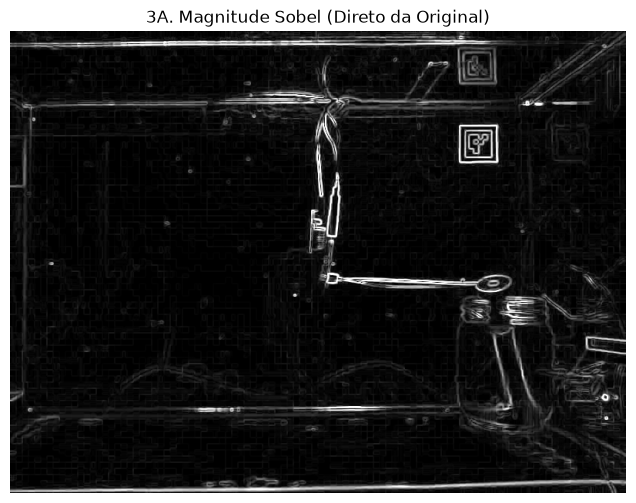

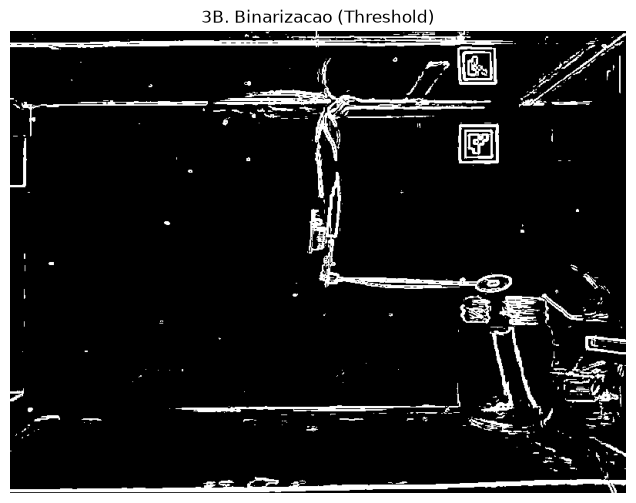

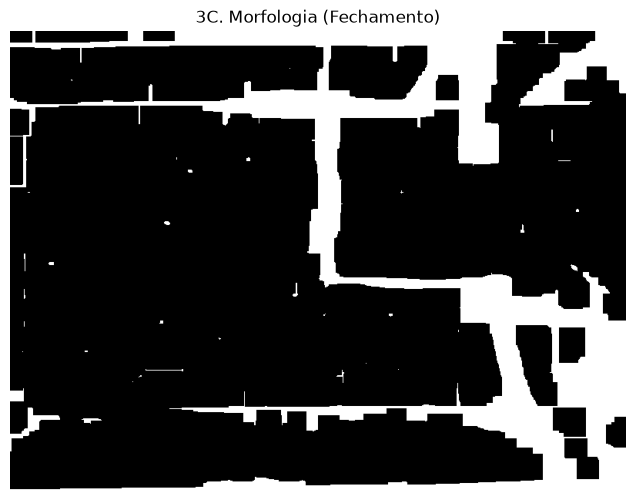

In [14]:
# 1. Derivadas Direcionais (Filtro de Sobel) direto na imagem original
# Usamos a variável 'gray' diretamente, sem nenhum desfoque prévio.
# CV_64F preserva os gradientes negativos antes do cálculo da magnitude.
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3) # Detecta bordas verticais (paredes laterais)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3) # Detecta bordas horizontais (base e nível da água)

# 2. Magnitude do Gradiente
# Combina as duas direções para formar as bordas completas
sobel_magnitude = cv2.magnitude(sobel_x, sobel_y)
sobel_magnitude_8u = cv2.convertScaleAbs(sobel_magnitude)
show_image("3A. Magnitude Sobel (Direto da Original)", sobel_magnitude_8u, cmap='gray')

# 3. Binarização (Threshold)
# Como não usamos desfoque, a imagem terá mais detalhes finos. 
# Tudo que for gradiente forte (> 50) vira branco. 
_, sobel_thresh = cv2.threshold(sobel_magnitude_8u, 50, 255, cv2.THRESH_BINARY)
show_image("3B. Binarizacao (Threshold)", sobel_thresh, cmap='gray')

# 4. Fechamento Morfológico
# Tenta conectar as bordas criadas pelo Sobel para formar um objeto sólido para a etapa de contornos.
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
closed = cv2.morphologyEx(sobel_thresh, cv2.MORPH_CLOSE, kernel, iterations=4)
show_image("3C. Morfologia (Fechamento)", closed, cmap='gray')

Frasco não encontrado com os filtros espaciais atuais.


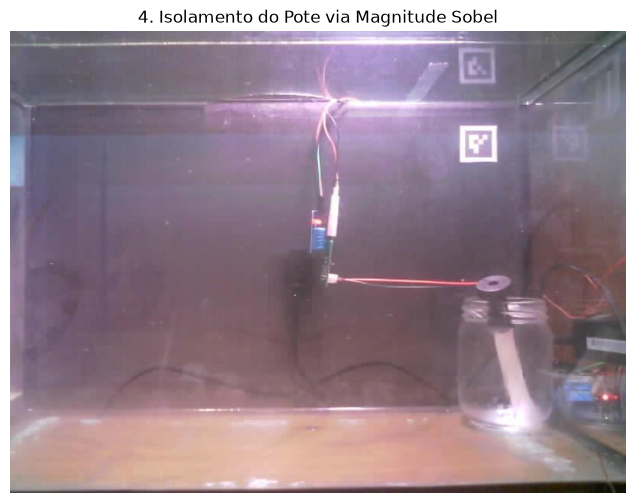

In [16]:
# Como a imagem sobel_magnitude_8u já destaca as bordas, vamos procurar
# o maior agrupamento de intensidade na metade inferior direita da imagem (onde o pote está).

h_img, w_img = sobel_magnitude_8u.shape

# Podemos usar um limiar bem suave apenas para ignorar o ruído quase preto (< 20)
# mas mantendo os gradientes em tons de cinza reais.
mask_sobel = np.zeros_like(sobel_magnitude_8u)
mask_sobel[sobel_magnitude_8u > 20] = 255

# Encontra contornos na máscara gerada pela magnitude
contours, _ = cv2.findContours(mask_sobel, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

image_contours = image.copy()
best_jar = None
max_score = 0

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    area = w * h
    
    # Filtro espacial: o pote está na metade inferior direita da imagem
    # E possui proporções características de altura/largura
    if w > 0 and x > w_img * 0.5 and y > h_img * 0.4:
        aspect_ratio = h / float(w)
        if 1000 < area < 50000 and 0.8 < aspect_ratio < 2.5:
            
            # Critério de pontuação: em vez de apenas área, podemos priorizar 
            # a soma real dos pixels de magnitude do Sobel dentro dessa caixa!
            roi_magnitude = sobel_magnitude_8u[y:y+h, x:x+w]
            score = np.sum(roi_magnitude)
            
            if score > max_score:
                max_score = score
                best_jar = (x, y, w, h)

if best_jar:
    x_jar, y_jar, w_jar_px, h_jar_px = best_jar
    cv2.rectangle(image_contours, (x_jar, y_jar), (x_jar + w_jar_px, y_jar + h_jar_px), (0, 255, 0), 3)
    print(f"Frasco isolado via Magnitude Sobel! Largura: {w_jar_px}px | Altura: {h_jar_px}px")
else:
    print("Frasco não encontrado com os filtros espaciais atuais.")

show_image("4. Isolamento do Pote via Magnitude Sobel", image_contours)